In [1]:
#!pip install mne
import mne
import numpy as np
import pandas as pd
from mne.datasets.sleep_physionet.age import fetch_data

In [2]:
# Download data for 2 subjects only (enough to start, full dataset is huge)
subjects = [0, 1]
recordings = fetch_data(subjects=subjects, recording=[1])

print(recordings)

Using default location ~/mne_data for PHYSIONET_SLEEP...
Creating /root/mne_data


  0%|                                              | 0.00/48.3M [00:00<?, ?B/s]

  0%|                                              | 0.00/4.62k [00:00<?, ?B/s]

  0%|                                              | 0.00/51.1M [00:00<?, ?B/s]

  0%|                                              | 0.00/3.90k [00:00<?, ?B/s]

Download complete in 09m16s (94.8 MB)
[['/root/mne_data/physionet-sleep-data/SC4001E0-PSG.edf', '/root/mne_data/physionet-sleep-data/SC4001EC-Hypnogram.edf'], ['/root/mne_data/physionet-sleep-data/SC4011E0-PSG.edf', '/root/mne_data/physionet-sleep-data/SC4011EH-Hypnogram.edf']]


In [5]:
import mne

# Load raw EEG for first subject
raw = mne.io.read_raw_edf(recordings[0][0], preload=True)
annotations = mne.read_annotations(recordings[0][1])

raw.set_annotations(annotations)

print(raw.info)


Extracting EDF parameters from /root/mne_data/physionet-sleep-data/SC4001E0-PSG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


/tmp/ipykernel_1219/3811619814.py:4: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(recordings[0][0], preload=True)
/tmp/ipykernel_1219/3811619814.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(recordings[0][0], preload=True)
/tmp/ipykernel_1219/3811619814.py:4: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(recordings[0][0], preload=True)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fpz-Cz, EEG Pz-Oz, EOG horizontal, Resp oro-nasal, EMG ...
 chs: 7 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 50.0 Hz
 meas_date: 1989-04-24 16:13:00 UTC
 nchan: 7
 projs: []
 sfreq: 100.0 Hz
 subject_info: <subject_info | his_id: X, sex: 2, first_name: Female, last_name: 33yr>
>


/tmp/ipykernel_1219/3811619814.py:7: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annotations)


In [6]:

print(raw.ch_names)

['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal', 'Resp oro-nasal', 'EMG submental', 'Temp rectal', 'Event marker']


In [8]:
# Keep only EEG channels
raw.pick_channels(['EEG Fpz-Cz', 'EEG Pz-Oz'])

# Bandpass filter 0.5 - 30 Hz (standard for sleep EEG)
raw.filter(0.5, 30.0)

print("Filtered. Channels:", raw.ch_names)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 661 samples (6.610 s)

Filtered. Channels: ['EEG Fpz-Cz', 'EEG Pz-Oz']


In [9]:
print("Sampling frequency:", raw.info['sfreq'])

Sampling frequency: 100.0


In [10]:
from mne.epochs import make_fixed_length_epochs

# Map sleep stage annotations to numbers
annotation_desc_2_event_id = {
    'Sleep stage W': 0,   # Wake
    'Sleep stage 1': 1,   # N1
    'Sleep stage 2': 2,   # N2
    'Sleep stage 3': 3,   # N3
    'Sleep stage 4': 3,   # N3 (same as stage 3)
    'Sleep stage R': 4,   # REM
}

events, event_id = mne.events_from_annotations(
    raw, event_id=annotation_desc_2_event_id, chunk_duration=30.0
)

print("Events shape:", events.shape)
print("Event IDs:", event_id)

# Create 30 second epochs
tmax = 30.0 - 1.0/raw.info['sfreq']
epochs = mne.Epochs(raw, events, event_id=event_id,
                    tmin=0.0, tmax=tmax,
                    baseline=None, preload=True)

print(epochs)

Used Annotations descriptions: [np.str_('Sleep stage 1'), np.str_('Sleep stage 2'), np.str_('Sleep stage 3'), np.str_('Sleep stage 4'), np.str_('Sleep stage R'), np.str_('Sleep stage W')]
Events shape: (2650, 3)
Event IDs: {np.str_('Sleep stage 1'): 1, np.str_('Sleep stage 2'): 2, np.str_('Sleep stage 3'): 3, np.str_('Sleep stage 4'): 3, np.str_('Sleep stage R'): 4, np.str_('Sleep stage W'): 0}
Not setting metadata
2650 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 2650 events and 3000 original time points ...
0 bad epochs dropped
<Epochs | 2650 events (all good), 0 – 29.99 s (baseline off), ~121.3 MiB, data loaded,
 np.str_('Sleep stage 1'): 58
 np.str_('Sleep stage 2'): 250
 np.str_('Sleep stage 3'): 220
 np.str_('Sleep stage 4'): 220
 np.str_('Sleep stage R'): 125
 np.str_('Sleep stage W'): 1997>


In [47]:
from scipy.signal import welch




In [46]:
# feature extraction in microvolts
def extract_band_powers_uv(epoch_data, sfreq=100.0):
    features = []
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'sigma': (12, 15),
        'beta': (13, 30)
    }

    for channel in epoch_data:
        channel_uv = channel * 1e6  # convert volts to microvolts
        freqs, psd = welch(channel_uv, fs=sfreq, nperseg=256)

        for band, (low, high) in bands.items():
            idx = np.where((freqs >= low) & (freqs <= high))
            band_power = np.mean(psd[idx])
            features.append(band_power)

    return features

X_uv = []
y = []

for i in range(len(epochs)):
    epoch_data = epochs[i].get_data()[0]
    features = extract_band_powers_uv(epoch_data)
    X_uv.append(features)
    y.append(epochs.events[i, 2])  # sleep stage label

X_uv = np.array(X_uv)
y = np.array(y)


In [12]:
print("Labels shape:", y.shape)
print("Unique labels:", np.unique(y))

Labels shape: (2650,)
Unique labels: [0 1 2 3 4]


In [51]:
#build dataframe
df_uv = pd.DataFrame(X_uv, columns=feature_names)
df_uv['sleep_stage'] = y
df_uv['stage_name'] = df_uv['sleep_stage'].map(stage_names)


In [50]:
display(df_uv.groupby('stage_name')[feature_names].mean().round(2))


,delta_ch1,theta_ch1,alpha_ch1,sigma_ch1,beta_ch1,delta_ch2,theta_ch2,alpha_ch2,sigma_ch2,beta_ch2
stage_name,,,,,,,,,,
N1,21.67,5.24,1.18,0.44,0.27,9.80,3.68,1.57,0.26,0.12
N2,55.29,6.26,1.49,1.44,0.23,21.41,3.19,0.71,0.45,0.09
N3,221.12,9.80,2.00,1.16,0.18,82.35,4.98,0.74,0.36,0.07
REM,13.83,4.41,0.92,0.32,0.15,7.63,2.83,1.31,0.20,0.07
Wake,100.82,9.46,1.77,1.08,0.89,7.49,1.71,1.25,0.73,0.54


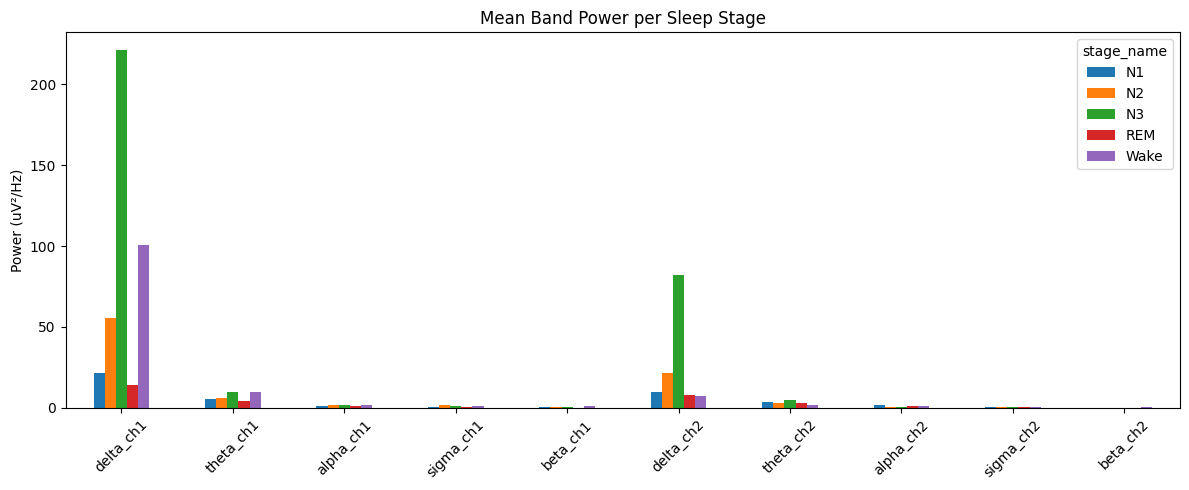

In [52]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = ['delta_ch1', 'theta_ch1', 'alpha_ch1', 'sigma_ch1', 'beta_ch1',
                 'delta_ch2', 'theta_ch2', 'alpha_ch2', 'sigma_ch2', 'beta_ch2']

df_features = pd.DataFrame(X_uv, columns=feature_names)
df_features['sleep_stage'] = y

stage_names = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}
df_features['stage_name'] = df_features['sleep_stage'].map(stage_names)

# Plot mean band power per sleep stage
df_features.groupby('stage_name')[feature_names].mean().T.plot(
    kind='bar', figsize=(12,5))
plt.title('Mean Band Power per Sleep Stage')
plt.ylabel('Power (uV²/Hz)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print("Class distribution:", dict(zip(unique, counts)))




Class distribution: {np.int64(0): np.int64(1997), np.int64(1): np.int64(58), np.int64(2): np.int64(250), np.int64(3): np.int64(220), np.int64(4): np.int64(125)}


In [54]:
# Correct approach - split first, then SMOTE only on training data
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_uv, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_raw, y_train_raw)


In [55]:

print("Train size:", X_train_sm.shape)
print("Test size:", X_test_raw.shape)

Train size: (7990, 10)
Test size: (530, 10)


In [56]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report



In [57]:
# Scale
scaler2 = StandardScaler()
X_train_sm_scaled = scaler2.fit_transform(X_train_sm)
X_test_sm_scaled = scaler2.transform(X_test_raw)

# Train RF
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train_sm, y_train_sm)
preds2 = rf2.predict(X_test_raw)

In [58]:
print("RF Accuracy", accuracy_score(y_test_raw, preds2))
print(classification_report(y_test_raw, preds2))

RF Accuracy 0.9566037735849057
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       399
           1       0.36      0.33      0.35        12
           2       0.85      0.92      0.88        50
           3       0.98      0.91      0.94        44
           4       0.83      0.80      0.82        25

    accuracy                           0.96       530
   macro avg       0.80      0.79      0.80       530
weighted avg       0.96      0.96      0.96       530



SVM

In [59]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_sm_scaled, y_train_sm)
svm_preds = svm.predict(X_test_sm_scaled)

print("SVM Accuracy", accuracy_score(y_test_raw, svm_preds))
print(classification_report(y_test_raw, svm_preds))

SVM Accuracy 0.9622641509433962
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       399
           1       0.50      0.50      0.50        12
           2       0.92      0.88      0.90        50
           3       0.93      0.93      0.93        44
           4       0.88      0.92      0.90        25

    accuracy                           0.96       530
   macro avg       0.84      0.84      0.84       530
weighted avg       0.96      0.96      0.96       530



In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(128, activation='relu', input_shape=(10,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')  # 5 classes now, not binary
])







/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [61]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [62]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


In [63]:
history = model.fit(X_train_sm_scaled, y_train_sm,
                    epochs=100,
                    batch_size=32,
                    validation_split=0.2,
                    callbacks=[early_stop],
                    verbose=1)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8415 - loss: 0.4889 - val_accuracy: 0.0601 - val_loss: 2.1890
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9194 - loss: 0.2441 - val_accuracy: 0.0626 - val_loss: 2.1920
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9305 - loss: 0.2109 - val_accuracy: 0.0626 - val_loss: 2.1432
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9374 - loss: 0.1764 - val_accuracy: 0.0620 - val_loss: 2.1055
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9454 - loss: 0.1605 - val_accuracy: 0.0626 - val_loss: 2.0785
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9423 - loss: 0.1615 - val_accuracy: 0.0776 - val_loss: 2.0180
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9493 - loss: 0.1496 - val_accuracy: 0.3116 - val_loss: 1.2603
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9528 - loss: 0.1398 - val_accu

In [64]:
y_pred_mlp = np.argmax(model.predict(X_test_sm_scaled), axis=1)
print("MLP Accuracy", accuracy_score(y_test_raw, y_pred_mlp))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
MLP Accuracy 0.9490566037735849


In [65]:
print(classification_report(y_test_raw, y_pred_mlp))


              precision    recall  f1-score   support

           0       0.99      0.99      0.99       399
           1       0.33      0.58      0.42        12
           2       0.88      0.88      0.88        50
           3       0.93      0.93      0.93        44
           4       0.94      0.60      0.73        25

    accuracy                           0.95       530
   macro avg       0.82      0.80      0.79       530
weighted avg       0.96      0.95      0.95       530

